## Customer Segmentation Analysis

### OIBSIP Data Analytics - Level 1 Task 2

#### Objective

The objective of this project is to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour.

RFM (Recency, Frequency and Monetary) analysis will be used to identify important customer behaviour patterns. K-Means clustering will then be applied to group customers into meaningful customer segments.

#### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- RFM Analysis
- K-Means Clustering

### 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

### 2. Load Dataset

The Online Retail dataset contains transaction-level information from an e-commerce retailer. It includes invoice information, products, quantities, prices, customer IDs and countries.

In [3]:
df = pd.read_csv(
    "CustomerSegmentationAnalysis.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


### 3. Data Inspection

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Handle Missing Values and Inconsistent Data

Typical issues in retail transaction exports:
- Missing `CustomerID` — can't attribute the row to a customer, so drop it.
- Missing `Description` — doesn't block RFM, but clean up for completeness.
- Cancelled orders (`InvoiceNo` starting with `C`) — returns, negative `Quantity`.
- Zero or negative `UnitPrice` — bad/adjustment rows.
- Duplicate rows — exact duplicate order lines from POS export glitches.

In [7]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Cancelled invoices (start with 'C'):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Rows with UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268
Cancelled invoices (start with 'C'): 9288
Rows with UnitPrice <= 0: 2517


In [8]:
# --- Cleaning pipeline ---
clean = df.copy()

# 1. Drop exact duplicate rows
clean = clean.drop_duplicates()

# 2. Drop rows with no CustomerID -- can't assign these to a segment
clean = clean.dropna(subset=["CustomerID"])
clean["CustomerID"] = clean["CustomerID"].astype(int)

# 3. Fill missing descriptions with a placeholder (not used in RFM, kept for completeness)
clean["Description"] = clean["Description"].fillna("UNKNOWN ITEM")

# 4. Flag cancellations (negative quantity / 'C' invoices) and drop them
#    from the *purchasing behaviour* view -- returns aren't purchases.
clean["IsCancelled"] = clean["InvoiceNo"].astype(str).str.startswith("C")
purchases = clean[(~clean["IsCancelled"]) & (clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)].copy()

# 5. Line-level revenue
purchases["LineTotal"] = purchases["Quantity"] * purchases["UnitPrice"]

print(f"Raw rows: {len(df):,}")
print(f"Rows after cleaning (genuine purchase lines): {len(purchases):,}")
print(f"Unique customers remaining: {purchases['CustomerID'].nunique():,}")

Raw rows: 541,909
Rows after cleaning (genuine purchase lines): 392,692
Unique customers remaining: 4,338


### 4. Descriptive Statistics

Average purchase value, purchase frequency, and customer lifetime value (CLV),
computed at the **order (invoice)** and **customer** level.

In [9]:
order_value = purchases.groupby("InvoiceNo")["LineTotal"].sum()
print(f"Average order value (AOV): £{order_value.mean():,.2f}")
print(f"Median order value:        £{order_value.median():,.2f}")

cust_orders = purchases.groupby("CustomerID")["InvoiceNo"].nunique()
print(f"\nAverage purchase frequency (orders/customer): {cust_orders.mean():.2f}")
print(f"Median purchase frequency:                    {cust_orders.median():.0f}")

clv = purchases.groupby("CustomerID")["LineTotal"].sum()
print(f"\nAverage Customer Lifetime Value (CLV, observed window): £{clv.mean():,.2f}")
print(f"Median CLV:  £{clv.median():,.2f}")
print(f"Total revenue in dataset: £{clv.sum():,.2f}")

Average order value (AOV): £479.56
Median order value:        £302.57

Average purchase frequency (orders/customer): 4.27
Median purchase frequency:                    2

Average Customer Lifetime Value (CLV, observed window): £2,048.69
Median CLV:  £668.57
Total revenue in dataset: £8,887,208.89


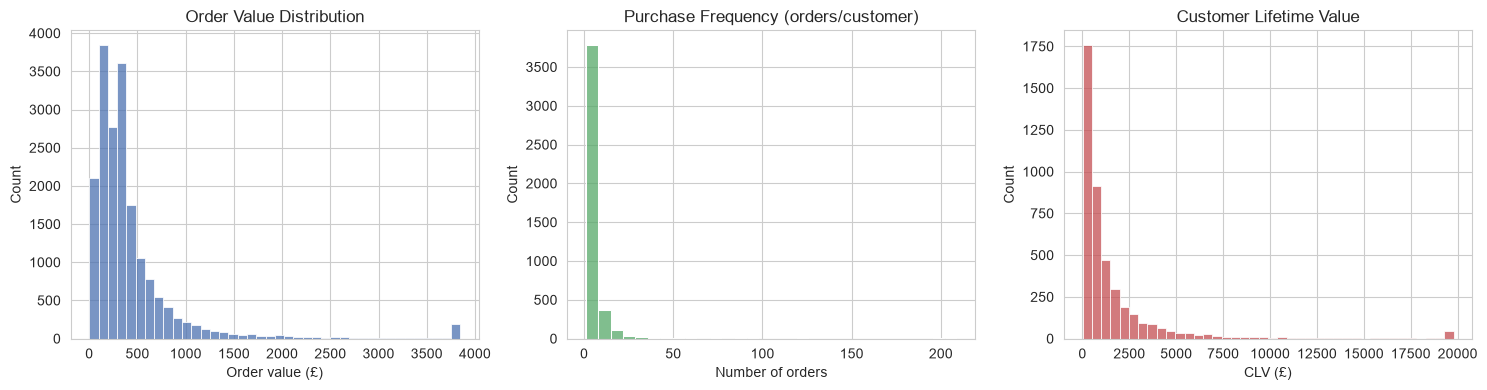

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(order_value.clip(upper=order_value.quantile(0.99)), bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Order Value Distribution")
axes[0].set_xlabel("Order value (£)")

sns.histplot(cust_orders, bins=30, ax=axes[1], color="#55A868")
axes[1].set_title("Purchase Frequency (orders/customer)")
axes[1].set_xlabel("Number of orders")

sns.histplot(clv.clip(upper=clv.quantile(0.99)), bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Customer Lifetime Value")
axes[2].set_xlabel("CLV (£)")

plt.tight_layout()
plt.show()

### Overall Observation
The distributions show that customer purchasing behaviour is highly uneven. Most customers are low-frequency and lower-value buyers, while a smaller group of highly active and valuable customers contributes significantly more to overall sales. These differences provide a strong basis for customer segmentation using RFM analysis and K-Means clustering.

### 5. Feature Selection — RFM Analysis

- **Recency (R):** days since the customer's most recent purchase (lower = more engaged)
- **Frequency (F):** number of distinct orders placed
- **Monetary (M):** total amount spent

In [11]:
# Convert InvoiceDate from string to datetime
purchases["InvoiceDate"] = pd.to_datetime(
    purchases["InvoiceDate"],
    errors="coerce"
)

# Check the data type
print(purchases["InvoiceDate"].dtype)

# Remove rows where InvoiceDate could not be converted
purchases = purchases.dropna(subset=["InvoiceDate"])

datetime64[us]


In [12]:
snapshot_date = purchases["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Snapshot (analysis) date:", snapshot_date.date())

rfm = purchases.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineTotal", "sum"),
).reset_index()

rfm.head()
rfm.head()

Snapshot (analysis) date: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [13]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### 6. Standardisation

K-Means uses Euclidean distance, so features on different scales (days vs.
order counts vs. pounds) would let `Monetary` dominate. We log-transform
`Monetary` first (it's right-skewed), then standardise all three features
with `StandardScaler` (mean 0, std 1).

In [14]:
rfm["MonetaryLog"] = np.log1p(rfm["Monetary"])

features = ["Recency", "Frequency", "MonetaryLog"]
X = rfm[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).describe().round(2)

,Recency,Frequency,MonetaryLog
count,4338.00,4338.00,4338.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-0.92,-0.43,-4.00
25%,-0.75,-0.43,-0.68
50%,-0.42,-0.30,-0.07
75%,0.49,0.09,0.66
max,2.81,26.60,4.73


### 7. K-Means Clustering — Elbow Method

Fit K-Means for a range of `k`, plot inertia to find the "elbow" — where
adding another cluster stops meaningfully reducing inertia.

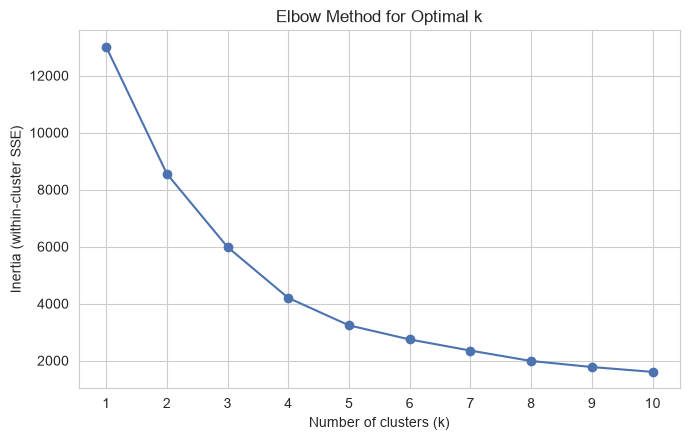

In [15]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), inertias, marker="o", color="#4C72B0")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

### Observation

- The inertia decreases sharply as the number of clusters increases from **k = 1 to k = 4**.
- After **k = 4**, the decrease in inertia becomes much more gradual.
- Therefore, the **elbow point appears around k = 4**, indicating that **4 clusters** provide a reasonable balance between cluster separation and model complexity.
- Based on this observation, **k = 4** can be selected as the optimal number of clusters for K-Means.

In [16]:
# Silhouette score as a second check to corroborate the elbow choice
from sklearn.metrics import silhouette_score

sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

for k, s in sil_scores.items():
    print(f"k={k}: silhouette={s:.3f}")

best_k_by_silhouette = max(sil_scores, key=sil_scores.get)
print(f"\nBest k by silhouette score: {best_k_by_silhouette}")

k=2: silhouette=0.372
k=3: silhouette=0.423
k=4: silhouette=0.417
k=5: silhouette=0.409
k=6: silhouette=0.365
k=7: silhouette=0.358
k=8: silhouette=0.351

Best k by silhouette score: 3


In [17]:
# Based on the elbow bend (~k=5) and silhouette score, we choose k=5.
K = 5

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm["Cluster"].value_counts().sort_index()

Cluster
0    1603
1    1542
2       8
3     214
4     971
Name: count, dtype: int64

### 8. Visualise Clusters

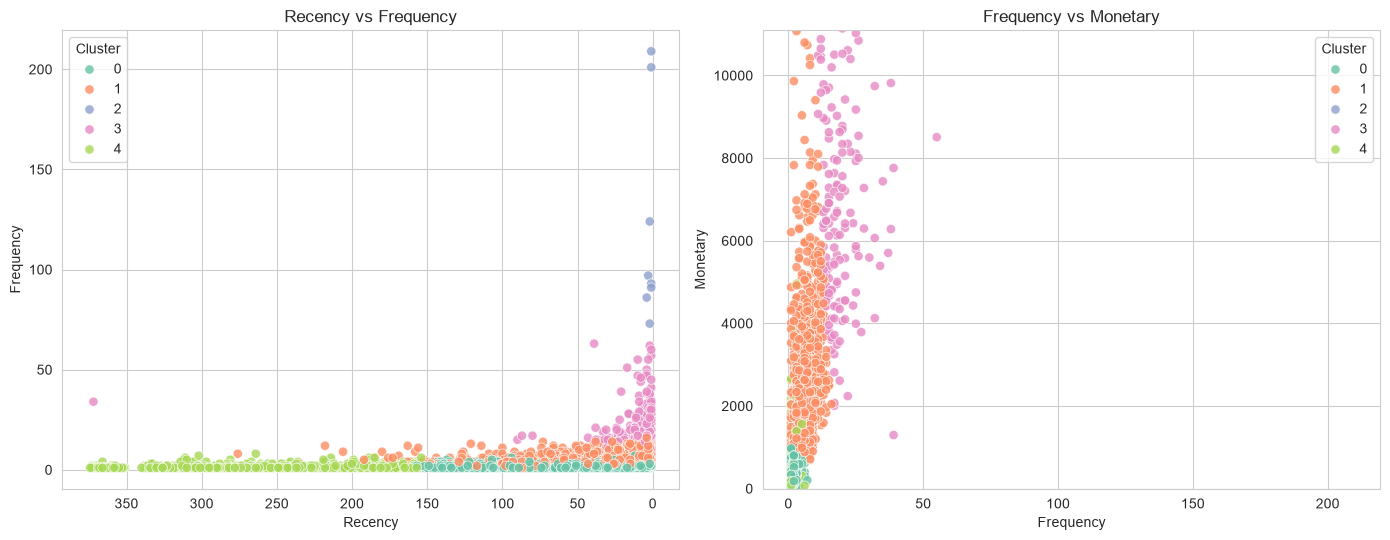

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
palette = sns.color_palette("Set2", K)

sns.scatterplot(
    data=rfm, x="Recency", y="Frequency", hue="Cluster",
    palette=palette, ax=axes[0], s=45, alpha=0.8
)
axes[0].set_title("Recency vs Frequency")
axes[0].invert_xaxis()

sns.scatterplot(
    data=rfm, x="Frequency", y="Monetary", hue="Cluster",
    palette=palette, ax=axes[1], s=45, alpha=0.8
)
axes[1].set_title("Frequency vs Monetary")
axes[1].set_ylim(0, rfm["Monetary"].quantile(0.98))

plt.tight_layout()
plt.show()

### Obseration 
The two plots agree with each other — the same customers
(Cluster 2) are extreme on both frequency and spend, and the same customers
(Cluster 4) are furthest from the origin on recency but not distinguished by
much else. This consistency across independent feature-pairs is a good sign
the k=5 clustering found real structure rather than an artifact of a single
dimension.

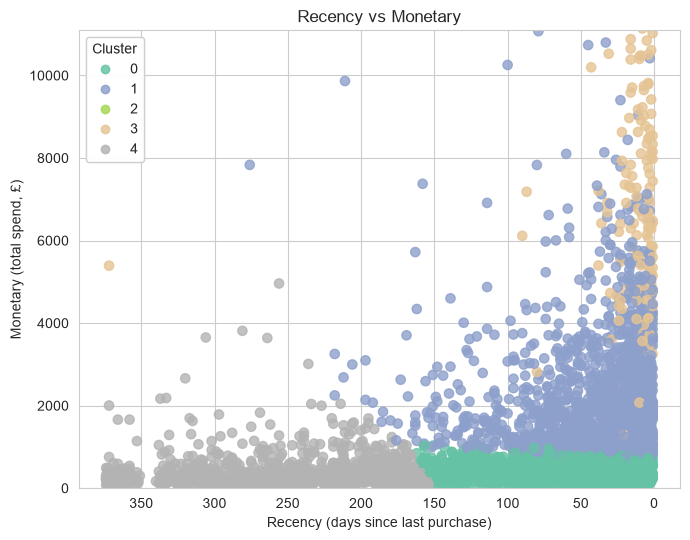

In [19]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(
    rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"],
    cmap="Set2", s=45, alpha=0.8
)
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary (total spend, £)")
ax.set_title("Recency vs Monetary")
ax.set_ylim(0, rfm["Monetary"].quantile(0.98))
ax.invert_xaxis()
legend = ax.legend(*sc.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

### Obseration
Recency does the heavy lifting for separating Hibernating from
everyone else, while monetary value is what separates the three "still
active" clusters (At Risk, Potential Loyalists, Loyal) from each other. This
confirms RFM's core premise — no single dimension tells the full story, but
the combination does.

### 9. Cluster Profiling

Mean RFM values per cluster, translated into a customer-type description.

In [20]:
profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
profile["CustomerCount"] = rfm["Cluster"].value_counts().sort_index()
profile["PctOfCustomers"] = (profile["CustomerCount"] / len(rfm) * 100).round(1)
profile = profile.sort_values("Monetary", ascending=False)
profile

,Recency,Frequency,Monetary,CustomerCount,PctOfCustomers
Cluster,,,,,
2,1.9,121.8,80018.9,8,0.2
3,12.0,22.2,16288.8,214,4.9
1,39.2,5.5,2399.1,1542,35.5
0,55.5,1.8,416.7,1603,37.0
4,256.8,1.5,405.6,971,22.4


In [21]:
# Label clusters by RANKING them against each other (not against the raw
# customer-level median). This is more robust on real, skewed retail data,
# where a handful of extreme spenders can drag the population median around
# and cause a naive per-customer threshold to mislabel several clusters.
#
# We combine R, F, M into one composite rank per cluster (standard RFM
# scoring practice), then map clusters -- best to worst -- onto a
# business-friendly tier scale.
r_rank = profile["Recency"].rank(method="min")                     # 1 = most recent (best)
f_rank = profile["Frequency"].rank(method="min", ascending=False)  # 1 = most frequent (best)
m_rank = profile["Monetary"].rank(method="min", ascending=False)   # 1 = highest spend (best)
composite_score = r_rank + f_rank + m_rank                         # lower = better overall

tier_names = ["Champions", "Loyal Customers", "Potential Loyalists",
              "At Risk / Needs Attention", "Hibernating"]
if K > len(tier_names):
    tier_names += [f"Tier {i}" for i in range(len(tier_names) + 1, K + 1)]
tier_names = tier_names[:K]

tier_order = composite_score.rank(method="first").astype(int) - 1  # 0-indexed position, best first
profile["Segment Label"] = tier_order.map(lambda pos: tier_names[pos])
profile

,Recency,Frequency,Monetary,CustomerCount,PctOfCustomers,Segment Label
Cluster,,,,,,
2,1.9,121.8,80018.9,8,0.2,Champions
3,12.0,22.2,16288.8,214,4.9,Loyal Customers
1,39.2,5.5,2399.1,1542,35.5,Potential Loyalists
0,55.5,1.8,416.7,1603,37.0,At Risk / Needs Attention
4,256.8,1.5,405.6,971,22.4,Hibernating


 ### Observation
At Risk and Hibernating together account for **59.4% of the
customer base**, making re-engagement the highest-leverage opportunity in
this dataset — while Champions and Loyal Customers, though just 5.1% of
customers by count, likely represent a disproportionate share of revenue
and deserve retention-focused attention rather than acquisition-style
marketing.

### 10. Customers per Cluster

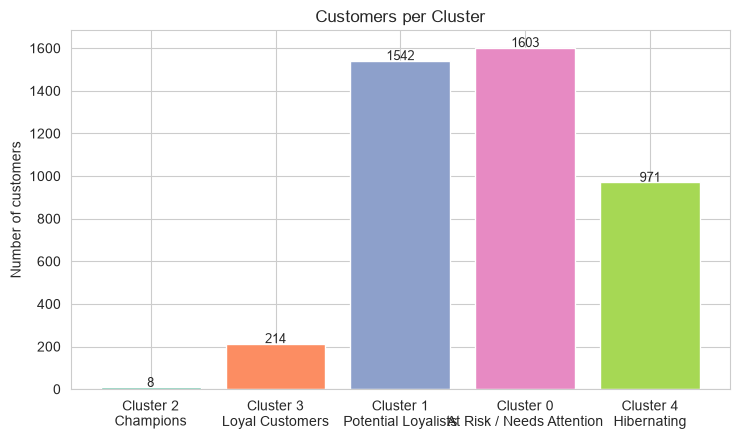

In [22]:
plt.figure(figsize=(7.5, 4.5))
order = profile.index
counts = rfm["Cluster"].value_counts().reindex(order)
bars = plt.bar(
    [f"Cluster {c}\n{profile.loc[c, 'Segment Label']}" for c in order],
    counts.values, color=sns.color_palette("Set2", K)
)
plt.ylabel("Number of customers")
plt.title("Customers per Cluster")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 2, str(val), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Observation
The customer base is concentrated mainly in the **At Risk / Needs Attention** and **Potential Loyalists** segments, while the **Champions** segment is very small. This suggests that there is significant opportunity to convert potential loyalists and at-risk customers into more valuable and engaged customers through targeted marketing strategies.

### 11. Insights & Recommended Marketing Actions

| Segment | Typical Profile | Recommended Action |
|---|---|---|
| **Champions** | Very recent, frequent, high spend | Loyalty/VIP programme, early access, ask for reviews/referrals |
| **Loyal Customers** | Recent, regular, moderate–high spend | Upsell/cross-sell, push toward Champion status |
| **New / Low Engagement** | Very recent first purchase(s) | Onboarding email series, second-purchase discount |
| **At Risk (high value)** | Used to spend well, recency slipping | Win-back campaign before they churn — highest priority |
| **Hibernating** | Long recency, low frequency/spend | Low-cost reactivation only; don't over-invest |